In [231]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt 

In [232]:
data = pd.read_csv('Datasets/train.csv')

data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [233]:
data = np.array(data)

m, n = data.shape # m = number of data, n = number of features + 1(label)
np.random.shuffle(data)

# Training on 1000 datasets and leaving the rest for testing
data_dev = data[0:1000].T
Y_dev = data_dev[0] # labels
X_dev = data_dev[1:n]
X_dev = X_dev / 255 # scaling the data into a range of 0 to 1. May not be necessary I think.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255

In [234]:
data

array([[4, 0, 0, ..., 0, 0, 0],
       [6, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [3, 0, 0, ..., 0, 0, 0],
       [8, 0, 0, ..., 0, 0, 0],
       [9, 0, 0, ..., 0, 0, 0]], shape=(42000, 785))

In [235]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 41000))

In [236]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5

    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1)) # size 0 to m and 9 + 1
    one_hot_Y[np.arange(Y.size), Y] = 1 # specifying the required column to be 1. 
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z): # slope is 1 if value is greater than 0 so this part is very simple.
    return Z > 0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    one_hot_Y = one_hot(Y)
    
    dZ2 = A2 - one_hot_Y # I thought this was supposed to be Z2 - one_hot_Y but that doesn't seem to be the case. This was causing issues.
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2) 

    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1) 

    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [237]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))

    return W1, b1, W2, b2

In [238]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, .1)

Iteration:  0
[4 5 5 ... 5 9 9] [5 6 0 ... 3 8 9]
Accuracy:  0.1557560975609756
Iteration:  50
[8 2 0 ... 3 3 3] [5 6 0 ... 3 8 9]
Accuracy:  0.4288048780487805
Iteration:  100
[8 6 0 ... 3 3 1] [5 6 0 ... 3 8 9]
Accuracy:  0.6550975609756098
Iteration:  150
[8 6 0 ... 3 3 7] [5 6 0 ... 3 8 9]
Accuracy:  0.7267073170731707
Iteration:  200
[0 6 0 ... 3 3 7] [5 6 0 ... 3 8 9]
Accuracy:  0.7640975609756098
Iteration:  250
[0 6 0 ... 3 3 7] [5 6 0 ... 3 8 9]
Accuracy:  0.787219512195122
Iteration:  300
[5 6 0 ... 3 3 7] [5 6 0 ... 3 8 9]
Accuracy:  0.8054634146341464
Iteration:  350
[5 6 0 ... 3 3 7] [5 6 0 ... 3 8 9]
Accuracy:  0.8194878048780487
Iteration:  400
[5 6 0 ... 3 8 7] [5 6 0 ... 3 8 9]
Accuracy:  0.8314390243902439
Iteration:  450
[5 6 0 ... 3 8 7] [5 6 0 ... 3 8 9]
Accuracy:  0.8399268292682927


In [239]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation = 'nearest')
    plt.show()

Prediction:  [6]
Label:  3


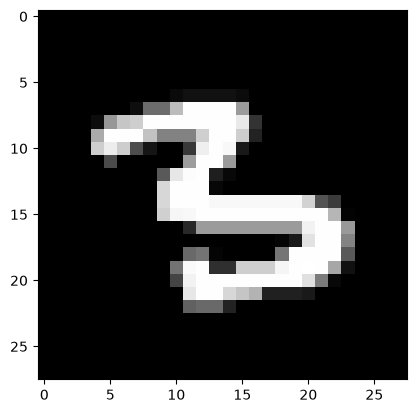

In [ ]:
test_prediction(450, W1, b1, W2, b2) # Mistaken prediction here

In [255]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[4 6 1 1 4 1 1 1 8 5 7 8 3 9 3 9 4 9 3 0 1 3 7 3 5 0 7 0 9 3 9 8 0 5 2 2 7
 9 8 8 2 1 8 8 6 4 7 8 8 1 2 0 4 1 6 9 7 0 9 3 6 7 2 7 0 1 3 6 6 2 0 2 3 2
 1 1 2 4 3 3 7 7 6 9 6 1 6 5 0 8 3 1 8 2 9 3 9 1 7 6 8 2 5 9 2 5 1 6 9 0 6
 9 6 3 4 8 1 6 4 4 5 1 5 9 4 4 1 0 5 1 5 6 5 8 8 4 0 4 2 6 4 4 9 2 1 0 3 5
 1 3 2 6 1 3 4 7 1 4 6 7 2 8 3 9 9 7 0 1 6 1 4 7 3 6 6 6 4 8 3 8 6 0 3 5 6
 1 5 4 0 5 2 3 6 9 8 9 1 8 8 6 0 5 6 7 5 7 7 9 9 0 0 4 3 0 3 2 5 4 4 7 2 7
 1 7 9 3 8 5 7 5 0 9 8 7 4 6 2 0 2 3 1 7 6 9 8 1 7 0 3 4 4 2 9 9 8 4 9 8 8
 2 7 7 2 5 6 7 2 8 6 8 3 7 9 9 8 1 6 9 4 8 2 5 1 9 6 2 2 1 8 5 3 2 7 7 9 1
 1 3 3 4 6 0 1 4 4 9 8 1 5 8 0 3 5 9 6 4 0 5 6 9 3 8 0 1 7 7 0 8 0 6 6 0 8
 4 6 8 3 0 6 7 0 5 7 7 5 6 5 7 1 7 2 2 0 2 6 2 9 3 0 3 2 9 3 8 0 4 5 1 2 1
 5 5 6 3 0 0 5 2 0 2 0 7 1 0 7 2 5 2 2 4 5 7 9 1 0 6 4 7 1 6 3 4 7 1 8 1 0
 0 6 8 7 7 2 9 4 6 4 9 7 7 4 8 6 4 8 9 0 7 7 4 6 0 0 5 3 4 1 0 7 6 9 9 8 0
 2 6 4 2 3 1 5 4 2 5 2 5 0 1 7 1 7 1 8 8 7 7 5 0 7 0 5 4 6 1 4 5 3 0 9 6 7
 5 5 0 0 7 7 2 3 5 4 8 0 

np.float64(0.845)